# Full per-role diversity analysis

Metric 3 (H2 mechanism): how much do the three models *diverge* in their per-role
outputs, on the balanced common-paper set across the homogeneous configs `All-A/B/C`.
Read from `eval/results/full/diversity.json`.

Two descriptive jobs only (not a diversity→quality regression):
- **Precondition** — models genuinely produce different content per role (diversity > 0).
- **Localization** — which role is most model-sensitive (feeds the seat-swap story).

`diversity = 1 - IRSim` (mean off-diagonal cosine similarity); `vendi_score` is the
effective number of distinct outputs, in `[1, n_models]`.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUN_SET = "full"

# Walk up until we find eval/ so the notebook runs regardless of CWD.
ROOT = Path.cwd()
while not (ROOT / "eval").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

RESULTS_DIR = ROOT / "eval" / "results" / RUN_SET
BATCHES = ROOT / "eval" / "batches.json"
FIG_DIR = ROOT / "eval" / "analysis" / "figures" / RUN_SET
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- palette (seaborn deep quad) ---
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
MODEL_COLORS = {"A": PALETTE[0], "B": PALETTE[1], "C": PALETTE[2]}
MODEL_NAMES = {"A": "qwen3-32b", "B": "mistral-small-3.2", "C": "llama-3.3-70b"}
ROLE_COLORS = dict(zip(
    ("leader", "clarity", "experiments", "impact"), PALETTE
))
ROLES = ("leader", "clarity", "experiments", "impact")
C_HET, C_REF = PALETTE[0], PALETTE[1]  # blue het, orange ref
C_ANNOT, C_MUTED, C_REF_LINE, C_EDGE, C_ERR = (
    "#333333", "#555555", "#666666", "#FFFFFF", "#333333",
)
# --- layout constants (fixed legend gap from figure bottom) ---
LEGEND_Y = 0.035          # figure coords — same on every plot
MARGIN_NO_LEGEND = 0.12
MARGIN_LEGEND = 0.22      # barh / scatter with legend, no rotated x
MARGIN_XROT30 = 0.28
MARGIN_XROT45 = 0.32
MARGIN_HEATMAP = 0.28
SAVE_PAD = 0.12


def legend_bottom(*, xrot=0, titled=False):
    if xrot >= 40:
        b = MARGIN_XROT45
    elif xrot >= 20:
        b = MARGIN_XROT30
    else:
        b = MARGIN_LEGEND
    if titled:
        b += 0.04
    return b


def legend_below(
    fig, ax=None, *, handles=None, labels=None, ncol=2, title=None, xrot=0,
):
    """Figure-level legend at fixed LEGEND_Y. Returns bottom margin for save_fig."""
    if handles is None:
        if ax is None:
            raise ValueError("legend_below needs ax or explicit handles")
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()
        handles, labels = ax.get_legend_handles_labels()
    kw = dict(
        loc="lower center", bbox_to_anchor=(0.5, LEGEND_Y), ncol=ncol,
        fontsize=8, framealpha=0.95, edgecolor="#CCCCCC", frameon=True,
    )
    if title:
        kw["title"] = title
    fig.legend(handles, labels, **kw)
    return legend_bottom(xrot=xrot, titled=title is not None)


def annotate_configs(ax, x, y, configs, *, fontsize=7, offsets_by_name=None):
    """Config slug near each scatter point."""
    defaults = [
        (7, 5), (7, -7), (-7, 5), (-7, -7),
        (10, 0), (-10, 0), (0, 9), (0, -9),
    ]
    for i, (xi, yi, name) in enumerate(zip(x, y, configs)):
        dx, dy = (offsets_by_name or {}).get(name, defaults[i % len(defaults)])
        ax.annotate(
            name, (xi, yi), textcoords="offset points", xytext=(dx, dy),
            fontsize=fontsize, color=C_ANNOT,
            ha="left" if dx >= 0 else "right",
            va="bottom" if dy >= 0 else "top",
        )


def pad_axes_for_labels(ax, *, xfrac=0.06, yfrac=0.08):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    ax.set_xlim(x0 - (x1 - x0) * xfrac, x1 + (x1 - x0) * xfrac)
    ax.set_ylim(y0 - (y1 - y0) * yfrac, y1 + (y1 - y0) * yfrac)


def save_fig(fig, path, *, bottom=MARGIN_NO_LEGEND, top=0.90, left=None, right=None):
    kw = dict(bottom=bottom, top=top)
    if left is not None:
        kw["left"] = left
    if right is not None:
        kw["right"] = right
    fig.subplots_adjust(**kw)
    fig.savefig(path, bbox_inches="tight", pad_inches=SAVE_PAD)


LEGEND_KW = dict(
    loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2,
    fontsize=8, framealpha=0.95, edgecolor="#CCCCCC", frameon=True,
)

FIG_RANK, FIG_COMPACT = (8.5, 4.5), (6, 3.6)
FIG_SCATTER, FIG_PANEL, FIG_WIDE = (7, 5), (9.5, 3.8), (12, 4.0)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 8,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.alpha": 0.25, "grid.color": "#E0E0E0", "grid.linestyle": "-",
    "lines.linewidth": 1.5, "patch.linewidth": 0.5,
})


def fig_title(desc: str, *, n_papers: int | None = None, extra: str = "") -> str:
    """Notebook title — keep light; LaTeX captions carry detail."""
    parts = []
    if RUN_SET == "pilot":
        parts.append("pilot")
    if n_papers is not None and (RUN_SET == "pilot" or n_papers != 25):
        parts.append(f"n={n_papers} papers")
    if extra:
        parts.append(extra)
    return f"{desc} ({', '.join(parts)})" if parts else desc


batch = json.loads(BATCHES.read_text())[RUN_SET]
pool = batch["pool"]
slug_to_letter = {v: k for k, v in pool.items()}


def letter(value: str) -> str:
    if value in pool:
        return value
    return slug_to_letter.get(value, value)


def tuple_letters(cfg: str) -> tuple[str, ...]:
    m = batch["configs"][cfg]
    return tuple(letter(m[r]) for r in ROLES)


def is_homogeneous(cfg: str) -> bool:
    return len(set(tuple_letters(cfg))) == 1


RESULTS = RESULTS_DIR / "diversity.json"
div = json.loads(RESULTS.read_text())

per_role = div["per_role"]
per_role_per_paper = div["per_role_per_paper"]
homo_configs = div["homogeneous_configs"]
papers = div["papers"]
n_models = len(homo_configs)

rows = []
for r in ROLES:
    agg = per_role.get(r, {})
    rows.append({
        "role": r,
        "diversity": agg.get("diversity", np.nan),
        "similarity": agg.get("similarity", np.nan),
        "vendi_score": agg.get("vendi_score", np.nan),
        "n_papers": agg.get("n_papers", 0),
    })
df = pd.DataFrame(rows)

print(f"run-set        : {RUN_SET}")
print(f"embedding model: {div['embedding_model']}")
print(f"configs (models): {homo_configs}")
print(f"common papers  : {div['n_papers']}  -> {papers}")
df.round(4)

run-set        : full
embedding model: all-MiniLM-L6-v2
configs (models): ['All-A', 'All-B', 'All-C']
common papers  : 7  -> ['7EhS3YBxjY', 'LFn7s8yRUF', 'MKpiaqh7R0', 'RwCxxaHvyp', 'aisfb733DW', 'bgcdO9lmug', 'pNxD5dpu1M']


,role,diversity,similarity,vendi_score,n_papers
0,leader,0.2002,0.7998,1.5387,7
1,clarity,0.3168,0.6832,1.8692,7
2,experiments,0.3454,0.6546,1.9735,7
3,impact,0.2010,0.7990,1.5811,7


## 1. Per-role diversity (precondition + localization)

Mean cross-model diversity per role, with the per-paper spread as error bars (min–max
over common papers). Higher = the three models say more different things in that seat.
The ordering is the localization signal.

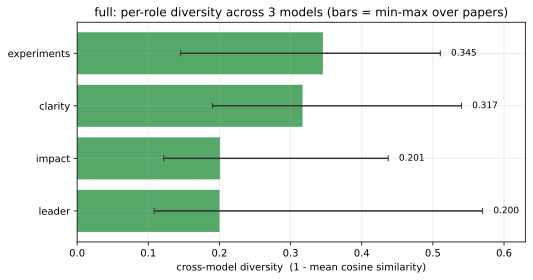

In [17]:
def per_paper_vals(role, field="diversity"):
    return [v[field] for v in per_role_per_paper.get(role, {}).values()]

d = df.sort_values("diversity")
means = d["diversity"].values
los, his = [], []
for r in d["role"]:
    vals = per_paper_vals(r)
    if vals:
        los.append(means[list(d["role"]).index(r)] - min(vals))
        his.append(max(vals) - means[list(d["role"]).index(r)])
    else:
        los.append(0); his.append(0)

bar_y = np.arange(len(d))
fig, ax = plt.subplots(figsize=FIG_RANK)
ax.barh(bar_y, d["diversity"], xerr=[los, his],
        color=ROLE_COLORS["experiments"], error_kw={"ecolor": C_ERR, "capsize": 3})

for yi, (v, hi) in enumerate(zip(d["diversity"].values, his)):
    ax.text(v + hi + 0.015, yi, f"{v:.3f}", va="center", fontsize=8)

ax.set_xlabel("cross-model diversity  (1 - mean cosine similarity)")
ax.set_title(fig_title("Per-role diversity across models", n_papers=div["n_papers"]))
max_x = max(d["diversity"] + his) if len(his) > 0 else max(d["diversity"])
ax.set_yticks(bar_y)
ax.set_yticklabels(d["role"].tolist(), fontsize=8)
ax.set_xlim(right=max_x + 0.08)
save_fig(fig, FIG_DIR / "diversity_by_role.png", bottom=MARGIN_NO_LEGEND)
plt.show()


## 2. Vendi score — effective number of distinct outputs

Complementary view in `[1, n_models]`. A value near 1 means the models collapse to one
voice in that seat; near `n_models` means they are mutually near-orthogonal.

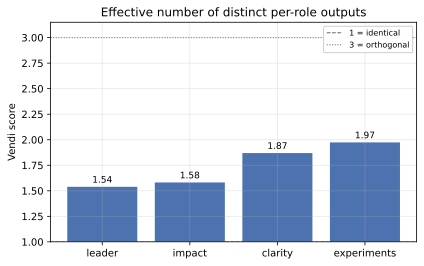

In [15]:
from matplotlib.lines import Line2D

d = df.sort_values("vendi_score")
fig, ax = plt.subplots(figsize=FIG_COMPACT)
bars = ax.bar(d["role"], d["vendi_score"], color=C_HET)
for b, v in zip(bars, d["vendi_score"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}",
            ha="center", va="bottom", fontsize=8)

ax.axhline(1.0, ls='--', color=C_REF_LINE, lw=1, zorder=0)
ax.axhline(n_models, ls=':', color=C_REF_LINE, lw=1, zorder=0)
ref_handles = [
    Line2D([0], [0], color=C_REF_LINE, ls="--", lw=1, label="1 = identical"),
    Line2D([0], [0], color=C_REF_LINE, ls=":", lw=1, label=f"{n_models} = orthogonal"),
]
bottom = legend_below(fig, handles=ref_handles,
                      labels=["1 = identical", f"{n_models} = orthogonal"], ncol=2)
ax.set_ylim(1.0, n_models + 0.15)
ax.set_ylabel("Vendi score")
ax.set_title(fig_title("Effective number of distinct per-role outputs", n_papers=div["n_papers"]))
save_fig(fig, FIG_DIR / "diversity_vendi.png", bottom=bottom)
plt.show()


## 3. Per-paper spread

Diversity is macro-averaged over papers, so check it is not driven by a couple of
outliers. Each line is a role across the common papers.

/var/folders/hc/xcxqtp9n6pl665jf8bb5860r0000gn/T/ipykernel_68429/2260552780.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(papers, rotation=45, ha="right", fontsize=8)


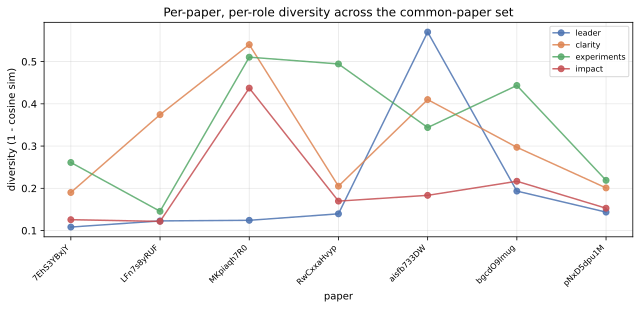

,leader,clarity,experiments,impact
7EhS3YBxjY,0.108,0.190,0.261,0.126
LFn7s8yRUF,0.123,0.374,0.146,0.122
MKpiaqh7R0,0.124,0.540,0.510,0.437
RwCxxaHvyp,0.140,0.205,0.494,0.170
aisfb733DW,0.570,0.410,0.344,0.183
bgcdO9lmug,0.193,0.297,0.443,0.217
pNxD5dpu1M,0.144,0.201,0.219,0.153


In [14]:
fig, ax = plt.subplots(figsize=FIG_PANEL)
for r in ROLES:
    by_paper = per_role_per_paper.get(r, {})
    xs = [p for p in papers if p in by_paper]
    ys = [by_paper[p]["diversity"] for p in xs]
    ax.plot(xs, ys, "o-", label=r, color=ROLE_COLORS[r], alpha=0.85)
ax.set_ylabel("diversity (1 - cosine sim)")
ax.set_xlabel("paper")
ax.set_title(fig_title("Per-paper, per-role diversity", n_papers=div["n_papers"]))
ax.set_xticks(range(len(papers)))
ax.set_xticklabels(papers, rotation=45, ha="right", fontsize=8)
bottom = legend_below(fig, ax, ncol=4, xrot=45)
save_fig(fig, FIG_DIR / "diversity_per_paper.png", bottom=bottom)
plt.show()

heat = pd.DataFrame(
    {r: {p: per_role_per_paper.get(r, {}).get(p, {}).get("diversity", np.nan) for p in papers}
     for r in ROLES}
)
display(heat.round(3))


## 4. Takeaways

_Fill once reviewed:_
1. **Precondition** — is per-role diversity comfortably above 0 for every seat (models
   really do differ), or does some seat collapse to one voice?
2. **Localization** — which seat is most model-sensitive? Cross-check against the
   experiments-seat win-rate effect: the seat that drives quality should also be a
   high-diversity seat.